<a href="https://colab.research.google.com/github/roshansadath/COMP6721_Winter2023_GroupN/blob/main/Simple%20Chest%20XRay/AlexNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [18]:
import os, time, random, torch, warnings
import numpy as np
from PIL import Image
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import precision_score, recall_score, f1_score

warnings.filterwarnings("ignore", category=UserWarning)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [19]:
#data_path = "/content/drive/MyDrive/Harvard_Chest_XRay/"
data_path = "/content/drive/MyDrive/Colab Notebooks/HealthCare AI/AI Driven Medical Imaging Models CNNs /Medical Image Diagnosis Convolutional Neural Networks/Simple_Chest_XRay/"
#data_path = "/content/drive/My Drive/NIH_Chest_XRay/"

sample_ratio = 1
batch_size = 96
num_epochs = 20

In [20]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [21]:
def save_metrics(loss, accuracy, model):
  np.save("{}{}_train_loss.npy".format(data_path, model), loss)
  np.save("{}{}_train_accuracy.npy".format(data_path, model), accuracy)

**DATA PREPROCESSING**

In [28]:
%run "/content/drive/MyDrive/Colab Notebooks/HealthCare AI/AI Driven Medical Imaging Models CNNs /Medical Image Diagnosis Convolutional Neural Networks/utils.ipynb"
dataset, train_loader, train_indices, test_loader, test_indices, val_loader, val_indices = data_preprocess(data_path, sample_ratio, batch_size)

**MODEL TRAINING**

In [29]:
# Define the AlexNet model and set Pretraining to False to train model from scratch
model = torch.hub.load('pytorch/vision:v0.10.0', 'alexnet', pretrained=False)
model.classifier[6] = nn.Linear(4096, len(dataset.classes))
model.to(device)

# Define loss function as CrossEntropy and optimizer as Adam Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.0001)
losses, accuracies, v_accuracies, v_losses = train_model(model, criterion, optimizer, "AlexNet", num_epochs)

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Evaluating on VALIDATION set: 100%|██████████| 1/1 [00:01<00:00,  1.24s/it]


VALIDATION Loss: 0.0000 Acc: 1.0000


Evaluating on VALIDATION set: 100%|██████████| 1/1 [00:00<00:00,  2.22it/s]


VALIDATION Loss: 0.0000 Acc: 1.0000


Evaluating on VALIDATION set: 100%|██████████| 1/1 [00:00<00:00,  2.32it/s]


...

VALIDATION Loss: 0.0000 Acc: 1.0000


Evaluating on VALIDATION set: 100%|██████████| 1/1 [00:00<00:00,  2.35it/s]


VALIDATION Loss: 0.0000 Acc: 1.0000


Evaluating on VALIDATION set: 100%|██████████| 1/1 [00:00<00:00,  2.35it/s]

VALIDATION Loss: 0.0000 Acc: 1.0000


In [30]:
torch.save(model.state_dict(), "{}alexnet.pth".format(data_path))

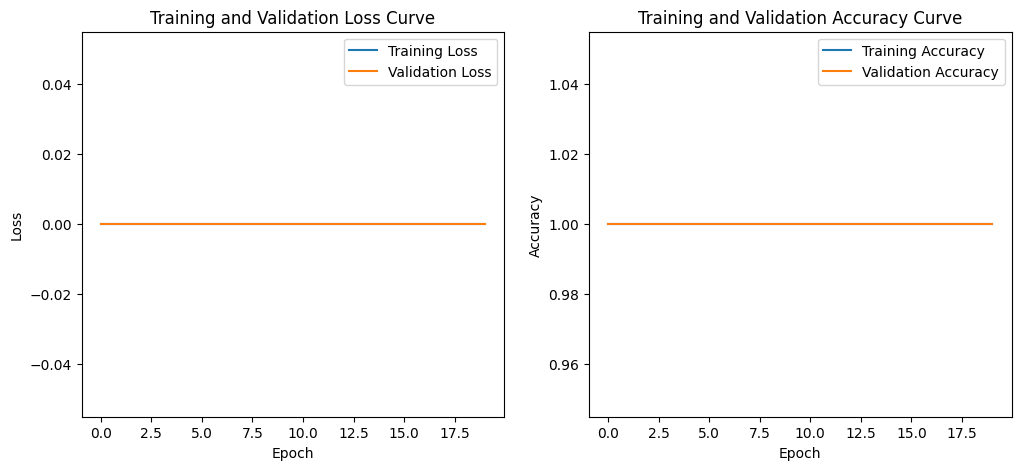

In [31]:
#Plotting the Loss and Accuracy Curves
plot_model_curves(losses, accuracies, v_accuracies, v_losses)

In [32]:
#Evaluate Model on Test Set
evaluate_model(model, test_loader, test_indices, 'TEST', criterion, data_path, "AlexNet")

Evaluating on TEST set: 100%|██████████| 1/1 [00:00<00:00,  1.43it/s]

TEST Loss: 0.0000 Acc: 1.0000


(tensor(1., dtype=torch.float64), 0.0)

In [33]:
#Obtain the TSNE Plot
plot_TSNE(train_loader, device, model)

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


ValueError: perplexity must be less than n_samples

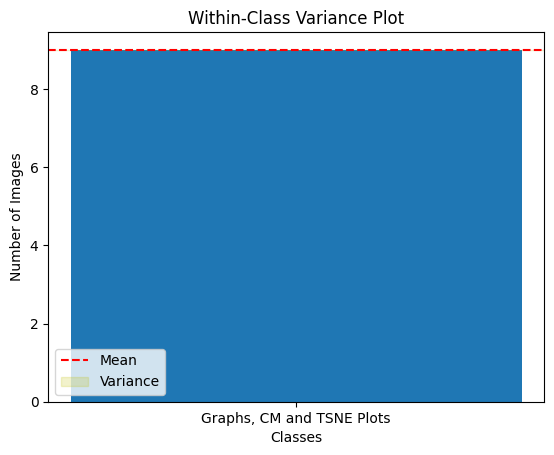

In [34]:
#Plot the Within-Class Variance of the dataset
plot_within_class_variance(dataset)